In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: C:\Users\HP\Documents\AI\Y1S2\ML\smartphone_ml_assignment
Data path exists: True


## 1) Problem Definition

- **Classification task:** predict `addiction_level`
- **Regression task:** predict `daily_screen_time_hours`

### Success criteria
- Classification: prioritize weighted F1, then accuracy/recall
- Regression: prioritize RMSE, then MAE and R2

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
summary = df.describe(include="all").T
summary.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,7500,7500,TXN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,7500,7500,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7500.0,NaN,NaN,NaN,26.5688,5.197108,18.0,22.0,27.0,31.0,35.0
gender,7500,3,Male,2553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_screen_time_hours,7500.0,NaN,NaN,NaN,7.499912,2.609188,3.0,5.22,7.525,9.81,12.0
social_media_hours,7500.0,NaN,NaN,NaN,3.273484,1.585342,0.5,1.91,3.27,4.63,6.0
gaming_hours,7500.0,NaN,NaN,NaN,2.014183,1.146039,0.0,1.02,2.04,2.99,4.0
work_study_hours,7500.0,NaN,NaN,NaN,3.24242,1.600765,0.5,1.85,3.23,4.64,6.0
sleep_hours,7500.0,NaN,NaN,NaN,6.737561,1.283605,4.5,5.63,6.72,7.84,9.0
notifications_per_day,7500.0,NaN,NaN,NaN,134.257333,66.586883,20.0,76.0,134.0,191.0,250.0


## 2) Data Cleaning Checks

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
missing_report[missing_report["missing_count"] > 0].head(20)

,missing_count,missing_percent
addiction_level,819,10.92


In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
outlier_report = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_count = ((df[col] < low) | (df[col] > high)).sum()
    outlier_report[col] = {
        "outlier_count": int(outlier_count),
        "outlier_percent": round((outlier_count / len(df)) * 100, 2),
    }

pd.DataFrame(outlier_report).T.sort_values("outlier_percent", ascending=False).head(15)

,outlier_count,outlier_percent
age,0.0,0.0
daily_screen_time_hours,0.0,0.0
social_media_hours,0.0,0.0
gaming_hours,0.0,0.0
work_study_hours,0.0,0.0
sleep_hours,0.0,0.0
notifications_per_day,0.0,0.0
app_opens_per_day,0.0,0.0
weekend_screen_time,0.0,0.0
addicted_label,0.0,0.0


## 3) Exploratory Data Analysis (EDA)

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\381060739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="addiction_level", order=order, palette="viridis")


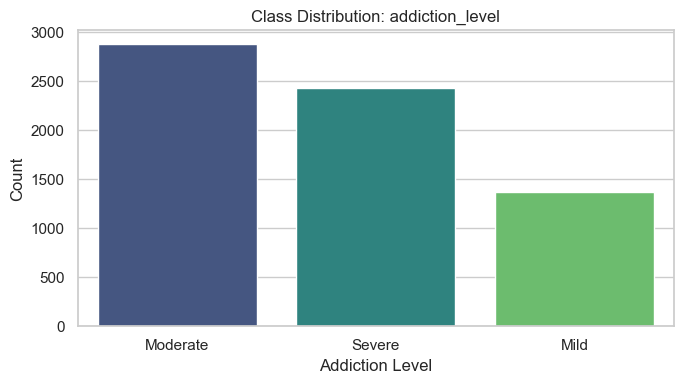

In [8]:
plt.figure(figsize=(7, 4))
order = df["addiction_level"].value_counts().index
sns.countplot(data=df, x="addiction_level", order=order, palette="viridis")
plt.title("Class Distribution: addiction_level")
plt.xlabel("Addiction Level")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_addiction_level.png", dpi=300)
plt.show()

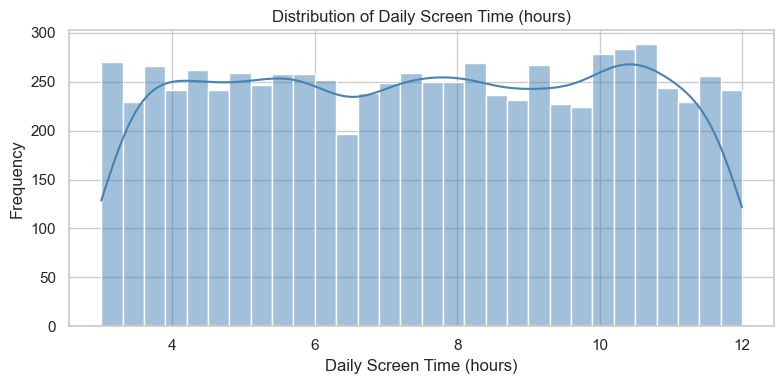

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["daily_screen_time_hours"], kde=True, bins=30, color="steelblue")
plt.title("Distribution of Daily Screen Time (hours)")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_screen_time_distribution.png", dpi=300)
plt.show()

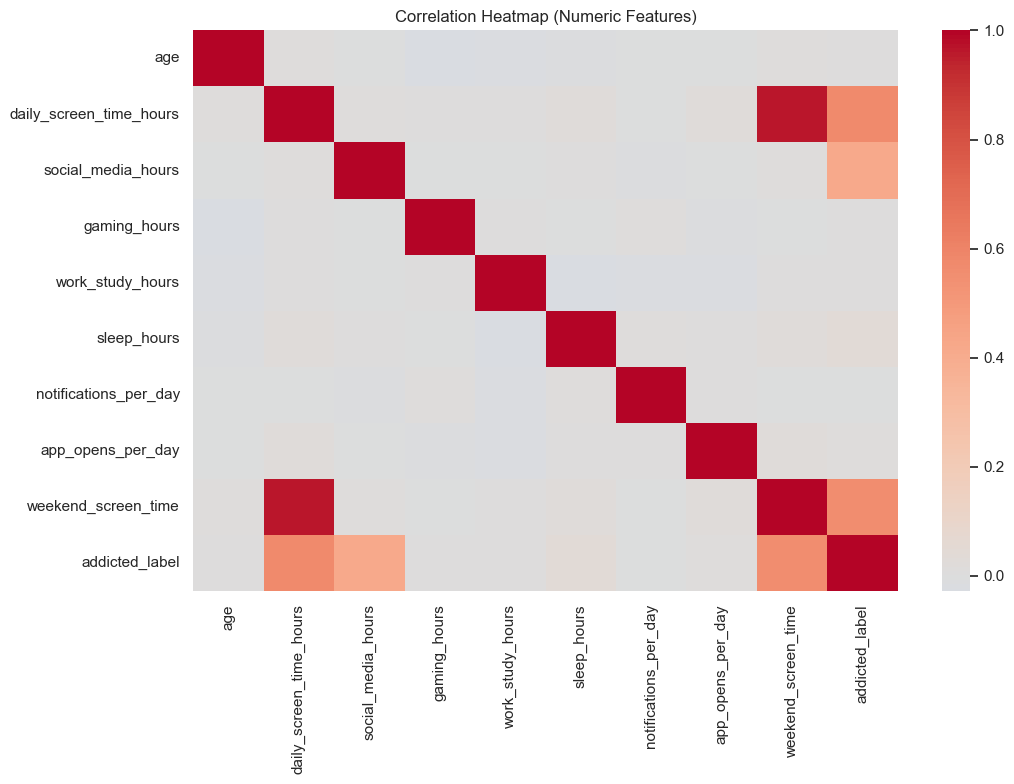

In [10]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


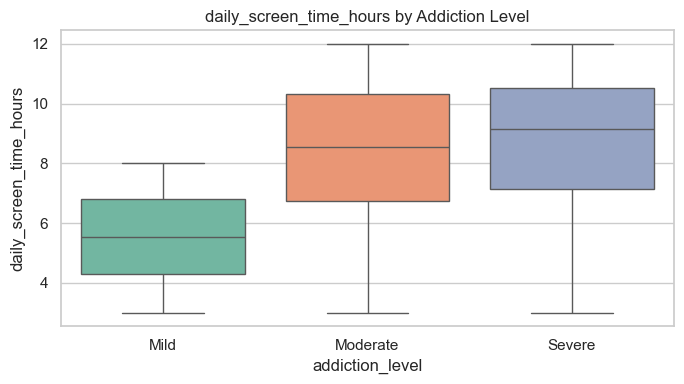

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


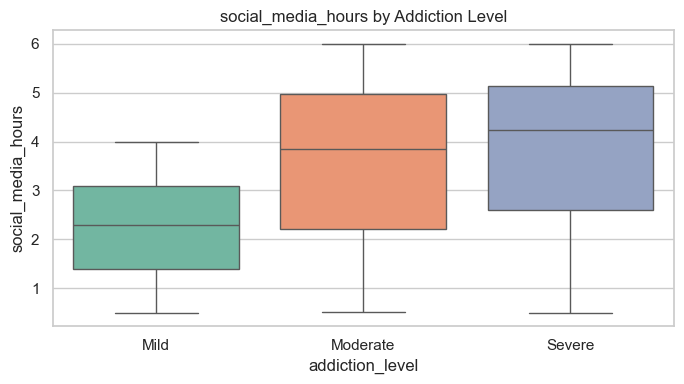

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


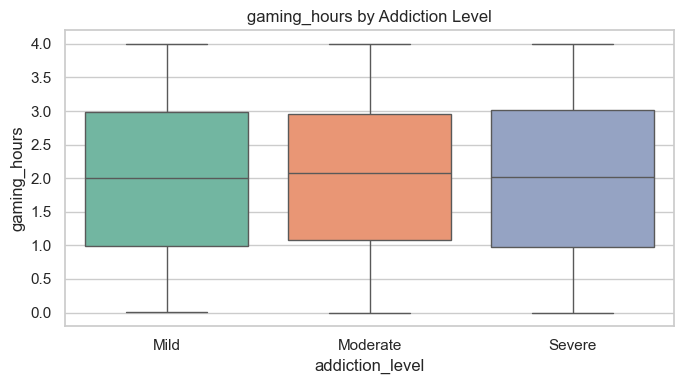

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


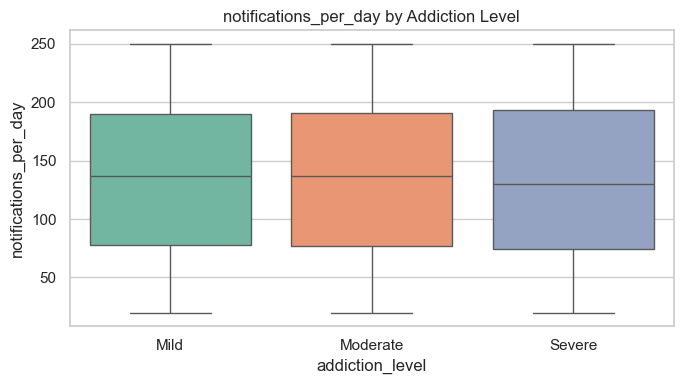

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


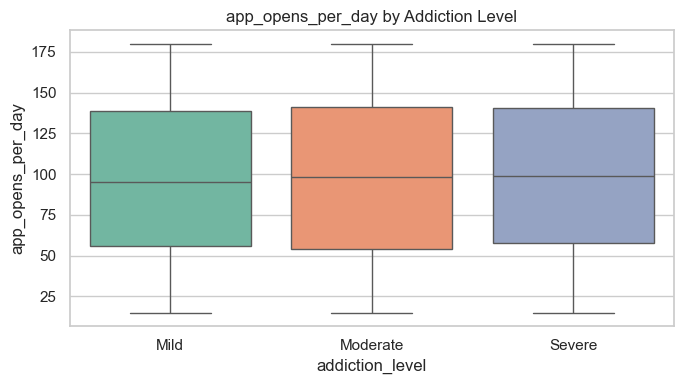

C:\Users\HP\AppData\Local\Temp\ipykernel_26872\2048547663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")


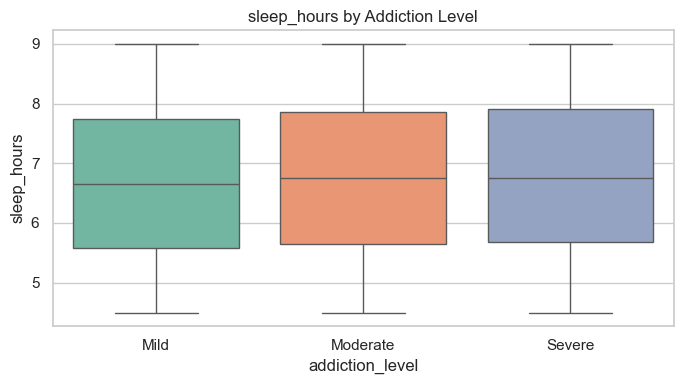

In [11]:
selected_features = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "sleep_hours",
]

for col in selected_features:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df, x="addiction_level", y=col, palette="Set2")
        plt.title(f"{col} by Addiction Level")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"box_{col}_by_addiction_level.png", dpi=300)
        plt.show()

In [12]:
top_corr_screen_time = corr["daily_screen_time_hours"].sort_values(ascending=False)
print("Top correlations with daily_screen_time_hours")
display(top_corr_screen_time.head(10))

if "addicted_label" in df.columns:
    top_corr_addicted = corr["addicted_label"].sort_values(ascending=False)
    print("Top correlations with addicted_label")
    display(top_corr_addicted.head(10))

Top correlations with daily_screen_time_hours


daily_screen_time_hours    1.000000
weekend_screen_time        0.964295
addicted_label             0.577112
app_opens_per_day          0.024448
sleep_hours                0.019343
age                        0.012767
social_media_hours         0.010321
work_study_hours           0.003108
gaming_hours               0.001140
notifications_per_day      0.000811
Name: daily_screen_time_hours, dtype: float64

Top correlations with addicted_label


addicted_label             1.000000
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day     -0.000660
Name: addicted_label, dtype: float64